In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df= pd.read_csv('1DataCoSupplyChainDataset.csv',encoding='latin-1')
df.head(50)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4.0,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,02-03-2018 22:56,Standard Class
1,TRANSFER,5,4.0,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4.0,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4.0,NaN,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4.0,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
5,TRANSFER,6,4.0,18.580000,294.980011,Shipping canceled,0,73,Sporting Goods,Tonawanda,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/19/2018 11:03,Standard Class
6,DEBIT,2,1.0,95.180000,288.420013,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 10:42,First Class
7,TRANSFER,2,1.0,68.430000,285.140015,Late delivery,1,73,Sporting Goods,Miami,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 10:21,First Class
8,CASH,3,2.0,NaN,278.589996,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 10:00,Second Class
9,CASH,2,1.0,132.149994,275.309998,Late delivery,1,73,Sporting Goods,San Ramon,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 9:39,First Class


### ------------------- DATA CLEANING AND EDA  -----------------------


In [23]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [24]:
dfTemp = df[['order date (DateOrders)','Order Item Total','Order Item Id','Product Card Id',
            'Customer Id','Customer Segment',
            'Days for shipping (real)','shipping date (DateOrders)',
            'Product Price','Shipping Mode','Type','Order Item Quantity','Order Item Discount','Order Profit Per Order']].copy()
dfTemp.head(50)

,order date (DateOrders),Order Item Total,Order Item Id,Product Card Id,Customer Id,Customer Segment,Days for shipping (real),shipping date (DateOrders),Product Price,Shipping Mode,Type,Order Item Quantity,Order Item Discount,Order Profit Per Order
0,1/31/2018 22:56,314.640015,180517.0,1360,20755.0,Consumer,3,02-03-2018 22:56,327.750000,Standard Class,DEBIT,1,13.110000,91.250000
1,1/13/2018 12:27,311.359985,179254.0,1360,19492.0,Consumer,5,1/18/2018 12:27,327.750000,Standard Class,TRANSFER,1,16.389999,-249.089996
2,1/13/2018 12:06,309.720001,179253.0,1360,19491.0,Consumer,4,1/17/2018 12:06,327.750000,Standard Class,CASH,1,18.030001,-247.779999
3,1/13/2018 11:45,304.809998,179252.0,1360,19490.0,Home Office,3,1/16/2018 11:45,327.750000,Standard Class,DEBIT,1,22.940001,22.860001
4,1/13/2018 11:24,298.250000,179251.0,1360,19489.0,Corporate,2,1/15/2018 11:24,327.750000,Standard Class,PAYMENT,1,29.500000,134.210007
5,1/13/2018 11:03,294.980011,179250.0,1360,19488.0,Consumer,6,1/19/2018 11:03,327.750000,Standard Class,TRANSFER,1,32.779999,18.580000
6,1/13/2018 10:42,288.420013,179249.0,1360,19487.0,Home Office,2,1/15/2018 10:42,327.750000,First Class,DEBIT,1,39.330002,95.180000
7,1/13/2018 10:21,285.140015,179248.0,1360,19486.0,Corporate,2,1/15/2018 10:21,327.750000,First Class,TRANSFER,1,42.610001,68.430000
8,1/13/2018 10:00,278.589996,179247.0,1360,19485.0,Corporate,3,1/16/2018 10:00,327.750000,Second Class,CASH,1,49.160000,133.720001
9,1/13/2018 9:39,275.309998,179246.0,1360,19484.0,Corporate,2,1/15/2018 9:39,327.750000,First Class,CASH,1,52.439999,132.149994


In [25]:
dfTemp.columns

Index(['order date (DateOrders)', 'Order Item Total', 'Order Item Id',
       'Product Card Id', 'Customer Id', 'Customer Segment',
       'Days for shipping (real)', 'shipping date (DateOrders)',
       'Product Price', 'Shipping Mode', 'Type', 'Order Item Quantity',
       'Order Item Discount', 'Order Profit Per Order'],
      dtype='object')

In [26]:
dfTemp.rename(
    columns={'order date (DateOrders)':"Order Date", 'Order Item Total':'Order Total','Product Card Id':'Product Id',
             'Days for shipping (real)':'Shipping Duration','Order Profit Per Order':'Profit Per Order','shipping date (DateOrders)':'Shipping Date',
             'Order Item Discount':'Total Discount','Order Item Quantity':'Total Quantity','Type':'Payment Type'
            },
    inplace = True
)

In [27]:
dfTemp.head(50)

,Order Date,Order Total,Order Item Id,Product Id,Customer Id,Customer Segment,Shipping Duration,Shipping Date,Product Price,Shipping Mode,Payment Type,Total Quantity,Total Discount,Profit Per Order
0,1/31/2018 22:56,314.640015,180517.0,1360,20755.0,Consumer,3,02-03-2018 22:56,327.750000,Standard Class,DEBIT,1,13.110000,91.250000
1,1/13/2018 12:27,311.359985,179254.0,1360,19492.0,Consumer,5,1/18/2018 12:27,327.750000,Standard Class,TRANSFER,1,16.389999,-249.089996
2,1/13/2018 12:06,309.720001,179253.0,1360,19491.0,Consumer,4,1/17/2018 12:06,327.750000,Standard Class,CASH,1,18.030001,-247.779999
3,1/13/2018 11:45,304.809998,179252.0,1360,19490.0,Home Office,3,1/16/2018 11:45,327.750000,Standard Class,DEBIT,1,22.940001,22.860001
4,1/13/2018 11:24,298.250000,179251.0,1360,19489.0,Corporate,2,1/15/2018 11:24,327.750000,Standard Class,PAYMENT,1,29.500000,134.210007
5,1/13/2018 11:03,294.980011,179250.0,1360,19488.0,Consumer,6,1/19/2018 11:03,327.750000,Standard Class,TRANSFER,1,32.779999,18.580000
6,1/13/2018 10:42,288.420013,179249.0,1360,19487.0,Home Office,2,1/15/2018 10:42,327.750000,First Class,DEBIT,1,39.330002,95.180000
7,1/13/2018 10:21,285.140015,179248.0,1360,19486.0,Corporate,2,1/15/2018 10:21,327.750000,First Class,TRANSFER,1,42.610001,68.430000
8,1/13/2018 10:00,278.589996,179247.0,1360,19485.0,Corporate,3,1/16/2018 10:00,327.750000,Second Class,CASH,1,49.160000,133.720001
9,1/13/2018 9:39,275.309998,179246.0,1360,19484.0,Corporate,2,1/15/2018 9:39,327.750000,First Class,CASH,1,52.439999,132.149994


In [28]:
# 314.64 = Consumer
# 304.80 = Home Office 
# 298.25 = Corporate

In [29]:
dfTemp.isnull().sum()

Order Date             0
Order Total          452
Order Item Id        439
Product Id             0
Customer Id          551
Customer Segment       0
Shipping Duration      0
Shipping Date          0
Product Price          0
Shipping Mode        679
Payment Type           0
Total Quantity         0
Total Discount         0
Profit Per Order       0
dtype: int64

<Axes: >

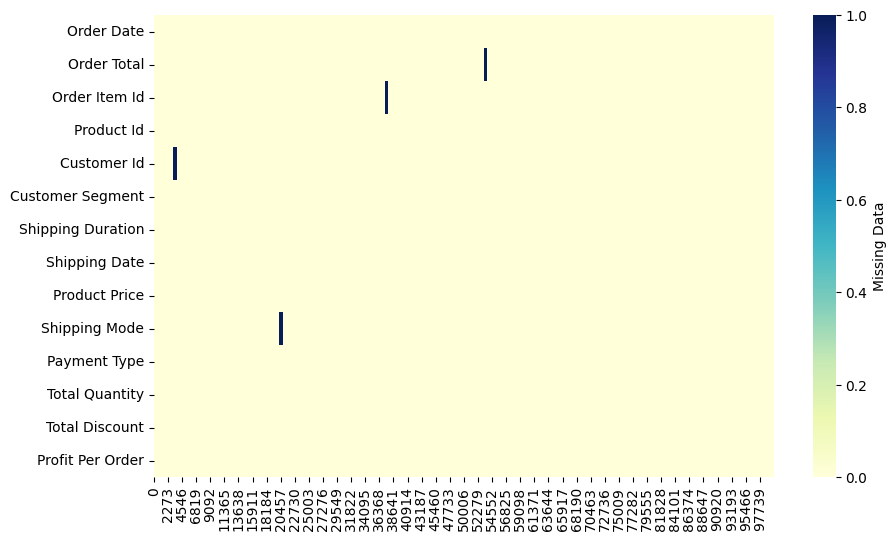

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(dfTemp.isna().transpose(),
            cmap="YlGnBu",
            cbar_kws={'label': 'Missing Data'})

In [31]:
dfTemp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99998 entries, 0 to 99997
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order Date         99998 non-null  object 
 1   Order Total        99546 non-null  float64
 2   Order Item Id      99559 non-null  float64
 3   Product Id         99998 non-null  int64  
 4   Customer Id        99447 non-null  float64
 5   Customer Segment   99998 non-null  object 
 6   Shipping Duration  99998 non-null  int64  
 7   Shipping Date      99998 non-null  object 
 8   Product Price      99998 non-null  float64
 9   Shipping Mode      99319 non-null  object 
 10  Payment Type       99998 non-null  object 
 11  Total Quantity     99998 non-null  int64  
 12  Total Discount     99998 non-null  float64
 13  Profit Per Order   99998 non-null  float64
dtypes: float64(6), int64(3), object(5)
memory usage: 10.7+ MB


In [32]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
dfTemp[['Customer Segment','Shipping Mode','Payment Type']]  = oe.fit_transform(dfTemp[['Customer Segment','Shipping Mode','Payment Type']])

In [33]:
from miceforest import ImputationKernel
ker = ImputationKernel(
    data = dfTemp.drop(['Order Date','Shipping Date'],axis=1),
    random_state=12345
)
ker.mice(3)
dfBase = ker.complete_data()

In [34]:
dfBase

,Order Total,Order Item Id,Product Id,Customer Id,Customer Segment,Shipping Duration,Product Price,Shipping Mode,Payment Type,Total Quantity,Total Discount,Profit Per Order
0,314.640015,180517.0,1360,20755.0,0.0,3,327.75,3.0,1.0,1,13.110000,91.250000
1,311.359985,179254.0,1360,19492.0,0.0,5,327.75,3.0,3.0,1,16.389999,-249.089996
2,309.720001,179253.0,1360,19491.0,0.0,4,327.75,3.0,0.0,1,18.030001,-247.779999
3,304.809998,179252.0,1360,19490.0,2.0,3,327.75,3.0,1.0,1,22.940001,22.860001
4,298.250000,179251.0,1360,19489.0,1.0,2,327.75,3.0,2.0,1,29.500000,134.210007
...,...,...,...,...,...,...,...,...,...,...,...,...
99993,143.940002,95540.0,1014,2084.0,1.0,5,49.98,2.0,1.0,3,6.000000,64.769997
99994,181.929993,95536.0,1014,6098.0,0.0,1,49.98,1.0,1.0,4,17.990000,30.930000
99995,179.929993,95530.0,1014,3817.0,1.0,4,49.98,3.0,1.0,4,19.990000,-149.880005
99996,87.959999,95521.0,1014,8308.0,0.0,4,49.98,3.0,2.0,2,12.000000,-19.790001


In [35]:
dfBase['Order Date'] = (pd.to_datetime(dfTemp['Order Date'],format='mixed').dt.date).astype('datetime64[ns]')
dfBase['Shipping Date'] = (pd.to_datetime(dfTemp['Shipping Date'],format='mixed').dt.date).astype('datetime64[ns]')

In [36]:
dfBase['Order Total'] = round(dfBase['Order Total'],2)
dfBase['Total Discount'] = round(dfBase['Total Discount'],2)
dfBase['Profit Per Order'] = round(dfBase['Profit Per Order'],2)

In [37]:
dfBase

,Order Total,Order Item Id,Product Id,Customer Id,Customer Segment,Shipping Duration,Product Price,Shipping Mode,Payment Type,Total Quantity,Total Discount,Profit Per Order,Order Date,Shipping Date
0,314.64,180517.0,1360,20755.0,0.0,3,327.75,3.0,1.0,1,13.11,91.25,2018-01-31,2018-02-03
1,311.36,179254.0,1360,19492.0,0.0,5,327.75,3.0,3.0,1,16.39,-249.09,2018-01-13,2018-01-18
2,309.72,179253.0,1360,19491.0,0.0,4,327.75,3.0,0.0,1,18.03,-247.78,2018-01-13,2018-01-17
3,304.81,179252.0,1360,19490.0,2.0,3,327.75,3.0,1.0,1,22.94,22.86,2018-01-13,2018-01-16
4,298.25,179251.0,1360,19489.0,1.0,2,327.75,3.0,2.0,1,29.50,134.21,2018-01-13,2018-01-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99993,143.94,95540.0,1014,2084.0,1.0,5,49.98,2.0,1.0,3,6.00,64.77,2016-07-12,2016-07-17
99994,181.93,95536.0,1014,6098.0,0.0,1,49.98,1.0,1.0,4,17.99,30.93,2016-07-12,2016-07-13
99995,179.93,95530.0,1014,3817.0,1.0,4,49.98,3.0,1.0,4,19.99,-149.88,2016-07-12,2016-07-16
99996,87.96,95521.0,1014,8308.0,0.0,4,49.98,3.0,2.0,2,12.00,-19.79,2016-07-12,2016-07-16


In [38]:
#  Calculation oF Gross Margin for each Customer
#  Revenue = Product Price + Discount
#  COGS = Order Total - Profit
# GM = (Revenue - COGS) / Revenue
cNumerator = ((dfBase['Product Price']*dfBase['Total Quantity']) + dfBase['Total Discount']
            - dfBase['Order Total']+dfBase['Profit Per Order'])
cRevenue = (dfBase['Product Price']*dfBase['Total Quantity']) + dfBase['Total Discount'] 
dfBase['Gross Margin'] = cNumerator/cRevenue
dfBase

,Order Total,Order Item Id,Product Id,Customer Id,Customer Segment,Shipping Duration,Product Price,Shipping Mode,Payment Type,Total Quantity,Total Discount,Profit Per Order,Order Date,Shipping Date,Gross Margin
0,314.64,180517.0,1360,20755.0,0.0,3,327.75,3.0,1.0,1,13.11,91.25,2018-01-31,2018-02-03,0.344628
1,311.36,179254.0,1360,19492.0,0.0,5,327.75,3.0,3.0,1,16.39,-249.09,2018-01-13,2018-01-18,-0.628552
2,309.72,179253.0,1360,19491.0,0.0,4,327.75,3.0,0.0,1,18.03,-247.78,2018-01-13,2018-01-17,-0.612297
3,304.81,179252.0,1360,19490.0,2.0,3,327.75,3.0,1.0,1,22.94,22.86,2018-01-13,2018-01-16,0.196014
4,298.25,179251.0,1360,19489.0,1.0,2,327.75,3.0,2.0,1,29.50,134.21,2018-01-13,2018-01-15,0.540826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99993,143.94,95540.0,1014,2084.0,1.0,5,49.98,2.0,1.0,3,6.00,64.77,2016-07-12,2016-07-17,0.492305
99994,181.93,95536.0,1014,6098.0,0.0,1,49.98,1.0,1.0,4,17.99,30.93,2016-07-12,2016-07-13,0.307053
99995,179.93,95530.0,1014,3817.0,1.0,4,49.98,3.0,1.0,4,19.99,-149.88,2016-07-12,2016-07-16,-0.499750
99996,87.96,95521.0,1014,8308.0,0.0,4,49.98,3.0,2.0,2,12.00,-19.79,2016-07-12,2016-07-16,0.037603


In [39]:
# aggre = {'Order Item Id':'count','Order Total':'sum','Order Date':['max','min'],'Gross Margin':'mean','Total Quantity':'sum'}
# aggreDf = dfBase.groupby('Customer Id').aggregate(aggre)
# aggreDf

### ---------------- Final DF -----------------------

In [106]:
# unique Customer Count
totalCorporateTransaction = dfBase['Order Item Id'].nunique()  # Total Corporate Transaction: 11857
totalUniqueCustomers = dfBase['Customer Id'].nunique()  # Unique Corporate Customers: 2812

aggre = {'Order Item Id':'count','Order Total':'sum','Order Date':['max','min'],'Gross Margin':'mean'}
aggreDf = dfBase.groupby('Customer Id').agg(aggre)

# Flatten the column index
aggreDf.columns = [' '.join(col).strip() for col in aggreDf.columns.values]

# Reset the index to make 'Customer Id' a regular column
aggreDf.reset_index(inplace=True)

# Rename Columns
aggreDf.rename(
    columns={'Order Item Id count':'Total Transactions','Order Total sum':'Order Total','Gross Margin mean':'Avg. Gross Margin'},
    inplace = True
)

# Duration between 1st and last transaction (in Days)
aggreDf['Customer LifeSpan ( Days )'] = (aggreDf['Order Date max'] - aggreDf['Order Date min']).apply(lambda x: max(x, pd.Timedelta(days=1)).days)

# Summation of LifeSpans of Customer in Month
LifeSpan = (aggreDf['Customer LifeSpan ( Days )'].sum() / 30 )
AvgLifeSpan = round(LifeSpan/totalUniqueCustomers,3)


aggreDf['Avg. LifeSpan'] = AvgLifeSpan
aggreDf['Avg. Order Value'] = round((aggreDf['Order Total']/aggreDf['Total Transactions']),3)
# aggreDf['Unique Customers'] = totalUniqueCustomers
aggreDf['CLV'] = round(
                            ( 
                                aggreDf['Avg. Order Value'] * 
                                aggreDf['Avg. Gross Margin'] * AvgLifeSpan 
                            ) ,3
                        )

#/ totalUniqueCustomers

In [107]:
aggreDf

,Customer Id,Total Transactions,Order Total,Order Date max,Order Date min,Avg. Gross Margin,Customer LifeSpan ( Days ),Avg. LifeSpan,Avg. Order Value,CLV
0,1.0,1,472.45,2015-12-01,2015-12-01,0.407034,1,10.812,472.450,2079.181
1,2.0,5,856.92,2017-04-26,2016-05-09,0.395831,352,10.812,171.384,733.477
2,3.0,6,615.82,2017-06-16,2015-12-12,-0.002279,552,10.812,102.637,-2.529
3,4.0,10,1040.53,2017-01-16,2015-05-12,0.185040,615,10.812,104.053,208.174
4,5.0,4,715.55,2016-10-31,2016-06-16,0.525129,137,10.812,178.888,1015.672
...,...,...,...,...,...,...,...,...,...,...
17467,20752.0,1,215.82,2018-01-31,2018-01-31,0.479983,1,10.812,215.820,1120.015
17468,20754.0,1,172.66,2018-01-31,2018-01-31,-0.155379,1,10.812,172.660,-290.061
17469,20755.0,1,314.64,2018-01-31,2018-01-31,0.344628,1,10.812,314.640,1172.387
17470,20756.0,1,10.91,2018-01-31,2018-01-31,0.229252,1,10.812,10.910,27.042


In [93]:
aggreDf.corr()

,Customer Id,Total Transactions,Order Total,Order Date max,Order Date min,Avg. Gross Margin,Customer LifeSpan ( Days ),Avg. LifeSpan,Avg. Order Value,CLV
Customer Id,1.000000,-0.508615,-0.472013,0.528841,0.749352,0.009296,-0.558850,-0.558850,0.137110,0.060068
Total Transactions,-0.508615,1.000000,0.951563,-0.137989,-0.688115,-0.008783,0.761591,0.761591,-0.147772,-0.063364
Order Total,-0.472013,0.951563,1.000000,-0.115681,-0.640064,-0.015216,0.717474,0.717474,0.077861,0.024867
Order Date max,0.528841,-0.137989,-0.115681,1.000000,0.600857,0.000032,-0.036687,-0.036687,0.120430,0.049820
Order Date min,0.749352,-0.688115,-0.640064,0.600857,1.000000,0.008020,-0.820862,-0.820862,0.197258,0.084219
Avg. Gross Margin,0.009296,-0.008783,-0.015216,0.000032,0.008020,1.000000,-0.009999,-0.009999,-0.022474,0.593165
Customer LifeSpan ( Days ),-0.558850,0.761591,0.717474,-0.036687,-0.820862,-0.009999,1.000000,1.000000,-0.160506,-0.069668
Avg. LifeSpan,-0.558850,0.761591,0.717474,-0.036687,-0.820862,-0.009999,1.000000,1.000000,-0.160506,-0.069668
Avg. Order Value,0.137110,-0.147772,0.077861,0.120430,0.197258,-0.022474,-0.160506,-0.160506,1.000000,0.383115
CLV,0.060068,-0.063364,0.024867,0.049820,0.084219,0.593165,-0.069668,-0.069668,0.383115,1.000000


In [94]:
X = aggreDf[['Avg. LifeSpan','Avg. Order Value','Avg. Gross Margin','Order Total','Total Transactions']]
Y = aggreDf['CLV']

In [95]:
# plt.figure(figsize = (12,8))
# sns.heatmap(X.corr(),annot= True)

In [96]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,train_size=0.7,random_state=9876)

In [97]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [98]:
y_true = y_test
y_predict = model.predict(x_test)

In [99]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
r2Score = r2_score(y_true,y_predict)
mae = mean_absolute_error(y_true,y_predict)
mse = mean_squared_error(y_true,y_predict)
rmse = np.sqrt(mse)

In [100]:
print(f"R2 Score: {r2Score:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f} and RMSE: {rmse:.2f}")

R2 Score: 0.43
MAE: 1.41
MSE: 28.65 and RMSE: 5.35


In [101]:
# plt.scatter(x_test[''],y_test)
# plt.scatter(x_test['Order Item Quantity'],y_predict,color = "red")